In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
vocab_size = 10000   # top 10k words
max_len = 200        # max review length
embedding_dim = 128
lstm_units = 128
batch_size = 64
epochs = 10

In [ ]:
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 25000
Testing samples: 25000


In [ ]:
X_train = pad_sequences(X_train, maxlen=max_len, padding='post', truncating='post')
X_test = pad_sequences(X_test, maxlen=max_len, padding='post', truncating='post')

In [ ]:
model = Sequential()

# Embedding Layer
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len))

# LSTM Layer
model.add(LSTM(lstm_units, return_sequences=False))

# Dropout for regularization
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=2)

history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 166s 522ms/step - accuracy: 0.5308 - loss: 0.6900 - val_accuracy: 0.5706 - val_loss: 0.6823
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 174s 557ms/step - accuracy: 0.5705 - loss: 0.6781 - val_accuracy: 0.5342 - val_loss: 0.6856
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 173s 554ms/step - accuracy: 0.6054 - loss: 0.6514 - val_accuracy: 0.5160 - val_loss: 0.7034


In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 106ms/step - accuracy: 0.4914 - loss: 0.6933
Test Loss: 0.6933040022850037
Test Accuracy: 0.49140000343322754


In [ ]:
word_index = imdb.get_word_index()

def encode_review(text):
    words = text.lower().split()
    encoded = []

    for word in words:
        if word in word_index and word_index[word] < vocab_size:
            encoded.append(word_index[word] + 3)
        else:
            encoded.append(2)  # unknown word

    return encoded

In [ ]:
review = "This movie was absolutely amazing and emotional"

encoded = encode_review(review)
padded = pad_sequences([encoded], maxlen=max_len)

prediction = model.predict(padded)[0][0]

print("Prediction Score:", prediction)

if prediction > 0.5:
    print("Sentiment: Positive 😊")
else:
    print("Sentiment: Negative 😞")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
Prediction Score: 0.5208593
Sentiment: Positive 😊


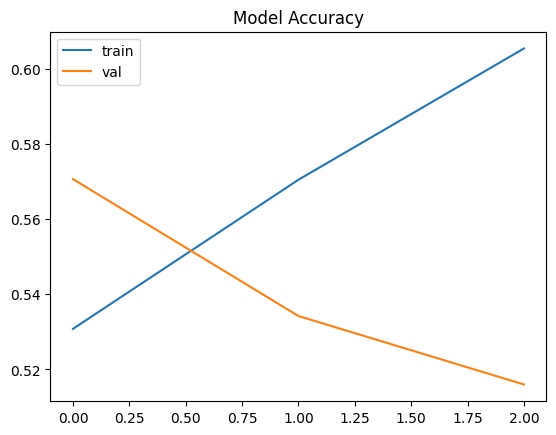

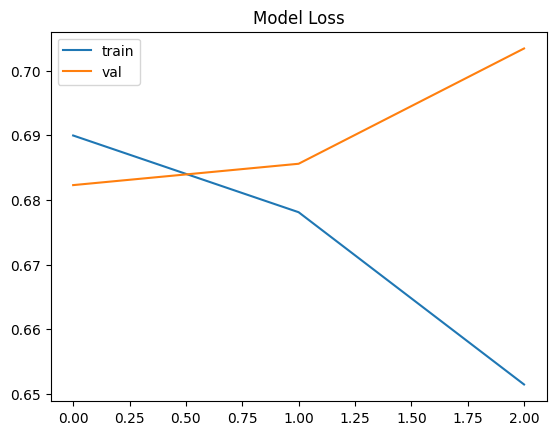

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Model Accuracy')
plt.legend()
plt.show()

# Loss
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Model Loss')
plt.legend()
plt.show()